In [1]:
!pip install mne

In [2]:
import mne
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing import image
from tensorflow.keras import models, layers

print("MNE Version:", mne.__version__)

MNE Version: 1.13.0


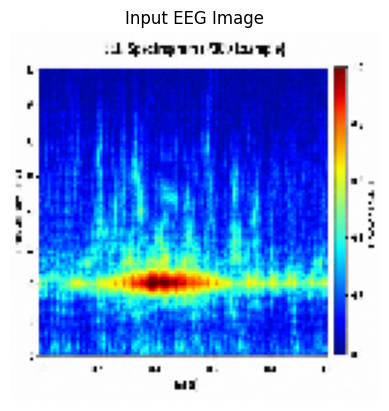

In [4]:
img = image.load_img(
    "eegimage.png",
    target_size=(128,128)
)

plt.imshow(img)
plt.title("Input EEG Image")
plt.axis("off")
plt.show()

In [6]:
img_array = image.img_to_array(img)

img_array = img_array / 255.0

img_array = np.expand_dims(img_array, axis=0)

print("Shape:", img_array.shape)

Shape: (1, 128, 128, 3)


In [7]:
model = models.Sequential([

    layers.Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(128,128,3)
    ),

    layers.MaxPooling2D(2,2),

    layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    layers.MaxPooling2D(2,2),

    layers.Flatten(),

    layers.Dense(
        128,
        activation='relu'
    ),

    layers.Dense(
        2,
        activation='softmax'
    )
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,578 (28.20 MB)

 Trainable params: 7,392,578 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
prediction = model.predict(img_array)

print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step
[[0.45748985 0.54251015]]


Image shape: (1024, 1536, 3)


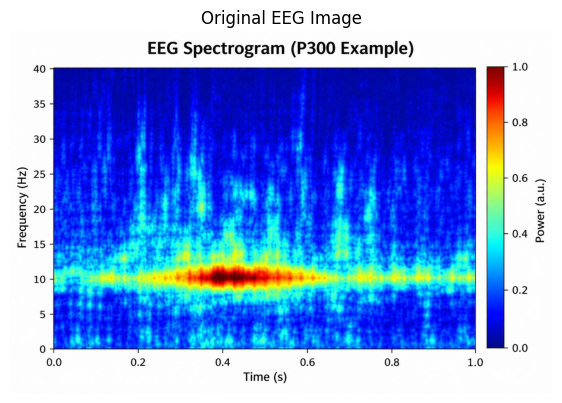

In [9]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("eegimage.png")

# Convert BGR to RGB
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Check image dimensions
print("Image shape:", img.shape)

plt.figure(figsize=(7,7))
plt.imshow(img)
plt.title("Original EEG Image")
plt.axis("off")
plt.show()

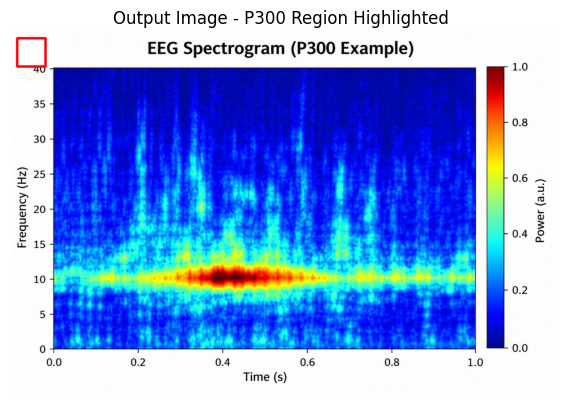

In [10]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("eegimage.png")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Highlight a larger region
cv2.rectangle(
    img,
    (20, 20),      # top-left
    (100, 100),    # bottom-right
    (255, 0, 0),   # red
    5              # thickness
)

plt.figure(figsize=(7,7))
plt.imshow(img)
plt.title("Output Image - P300 Region Highlighted")
plt.axis("off")
plt.show()